# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "all-sparse-reg" #"prim-Na-EE-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_protection,peff_toxicity
20,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
149,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
278,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
407,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
536,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40025630,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,5.302957e+06,783.724370,0.368939,0.215918,4.263644,0.0,20.0,20.0000,-8.7776,0.027191,1.122812,0.000533,6.028162e+06,3.349485,2.651569,0.000090,0.000392
40025759,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,5.302920e+06,963.710828,0.445028,0.264413,4.272375,0.0,20.0,20.0000,-5.1360,0.027191,1.122806,0.000659,6.028195e+06,3.349485,2.651569,0.000108,0.000482
40025888,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,5.302317e+06,3528.295515,1.086090,0.698499,4.217698,0.0,20.0,20.0000,-9.4800,0.027186,1.122714,0.002410,6.028750e+06,3.349485,2.651569,0.000410,0.001764
40026017,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,5.287471e+06,58227.795937,3.552002,1.233668,2.426244,0.0,20.0,5.1264,-11.3440,0.027066,1.120395,0.195402,6.042383e+06,3.349485,2.651569,0.007833,0.029114


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Threshold"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

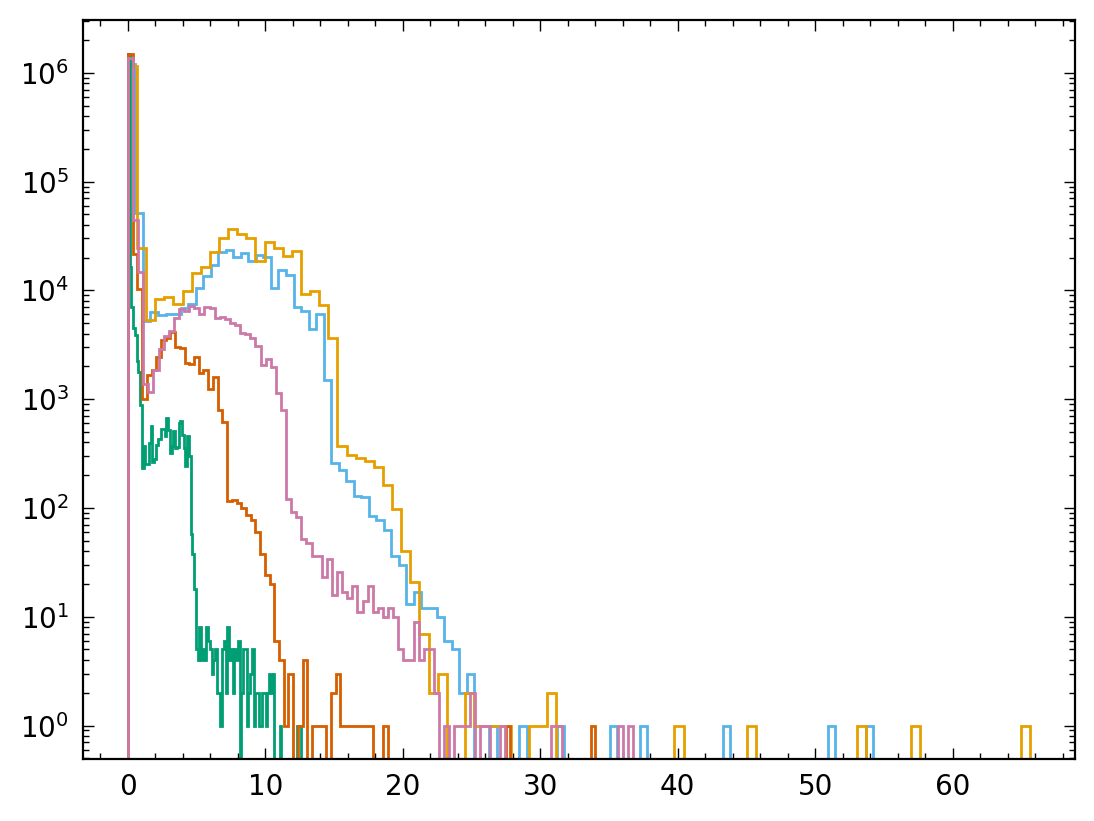

In [4]:
# Inspect distribution of observables
sel = 'peff_protection'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,-26.795884,1.681457,1.062424,0.660597
1,-6.698971,3.212137,1.055515,0.767523
2,0.700124,0.210929,1.162174,0.128207
3,0.717337,0.280461,1.341999,0.179550
4,0.735609,0.341194,1.457485,0.238624
...,...,...,...,...
100,2.677607,4.729134,1.638527,0.514291
101,2.813581,5.058417,1.663644,0.557237
102,3.349485,0.026993,1.117700,0.106464
103,5.359177,0.143154,1.114857,0.152336


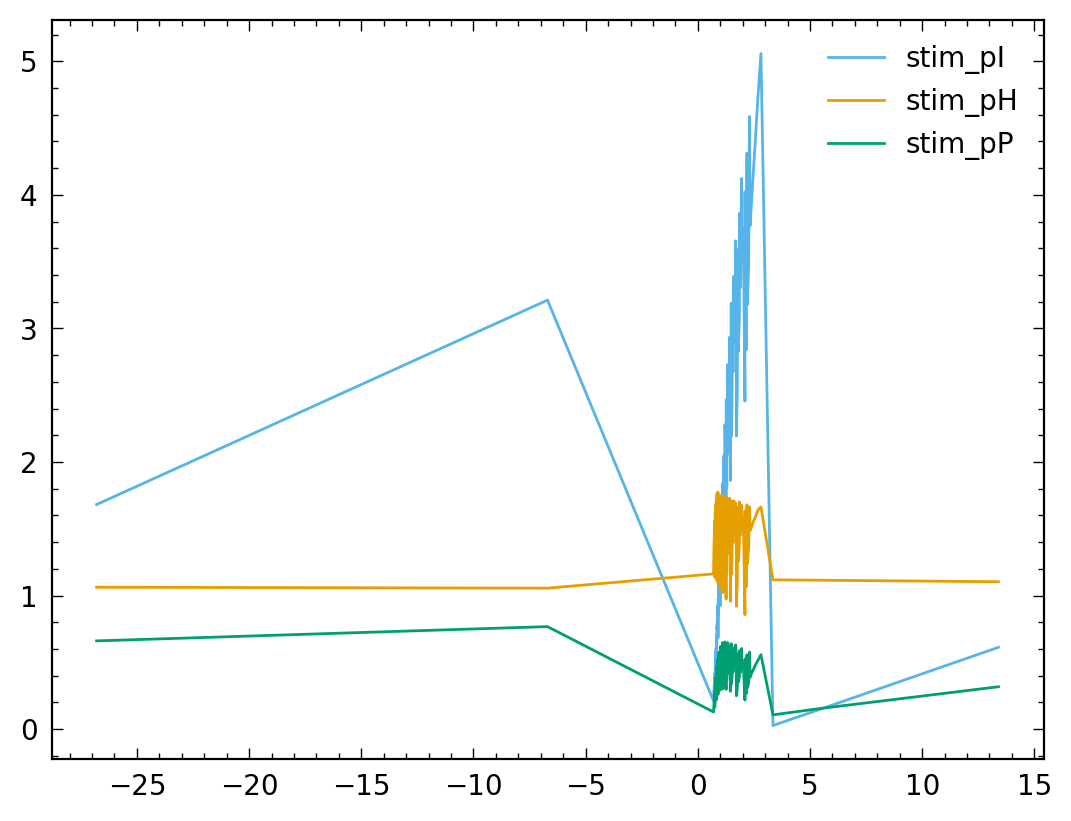

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 8
fevals: 12
fevals: 14
fevals: 56


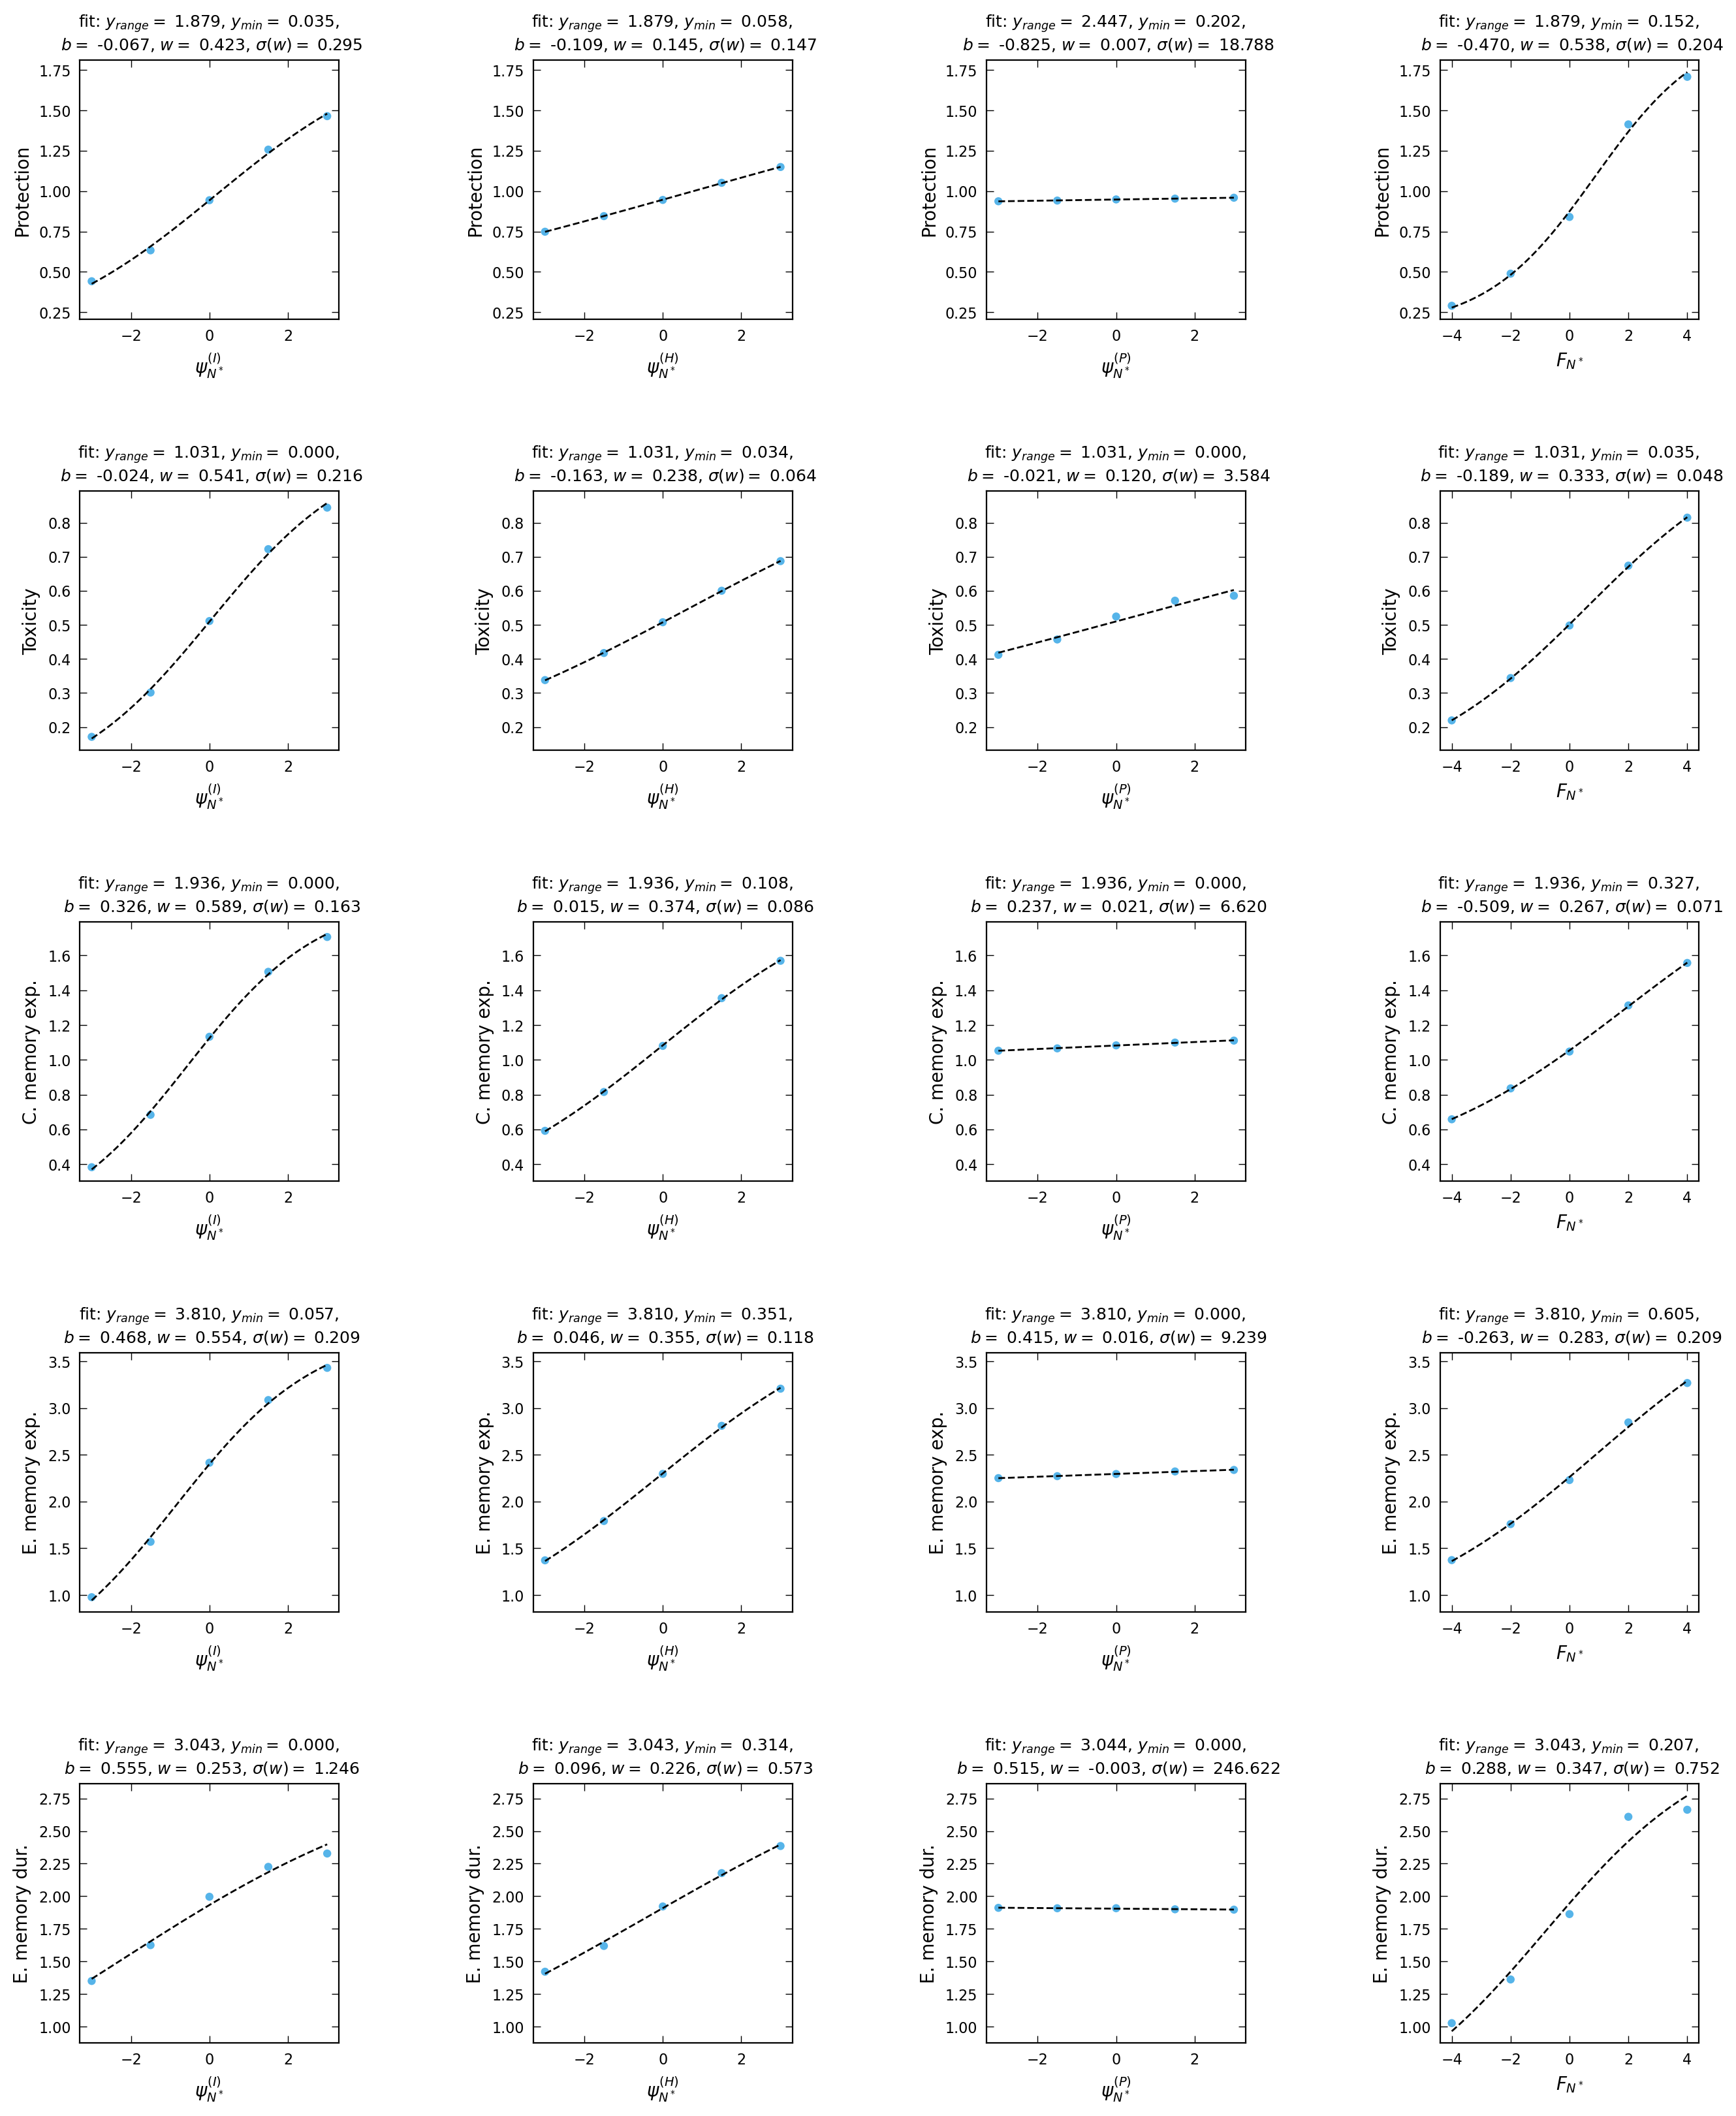

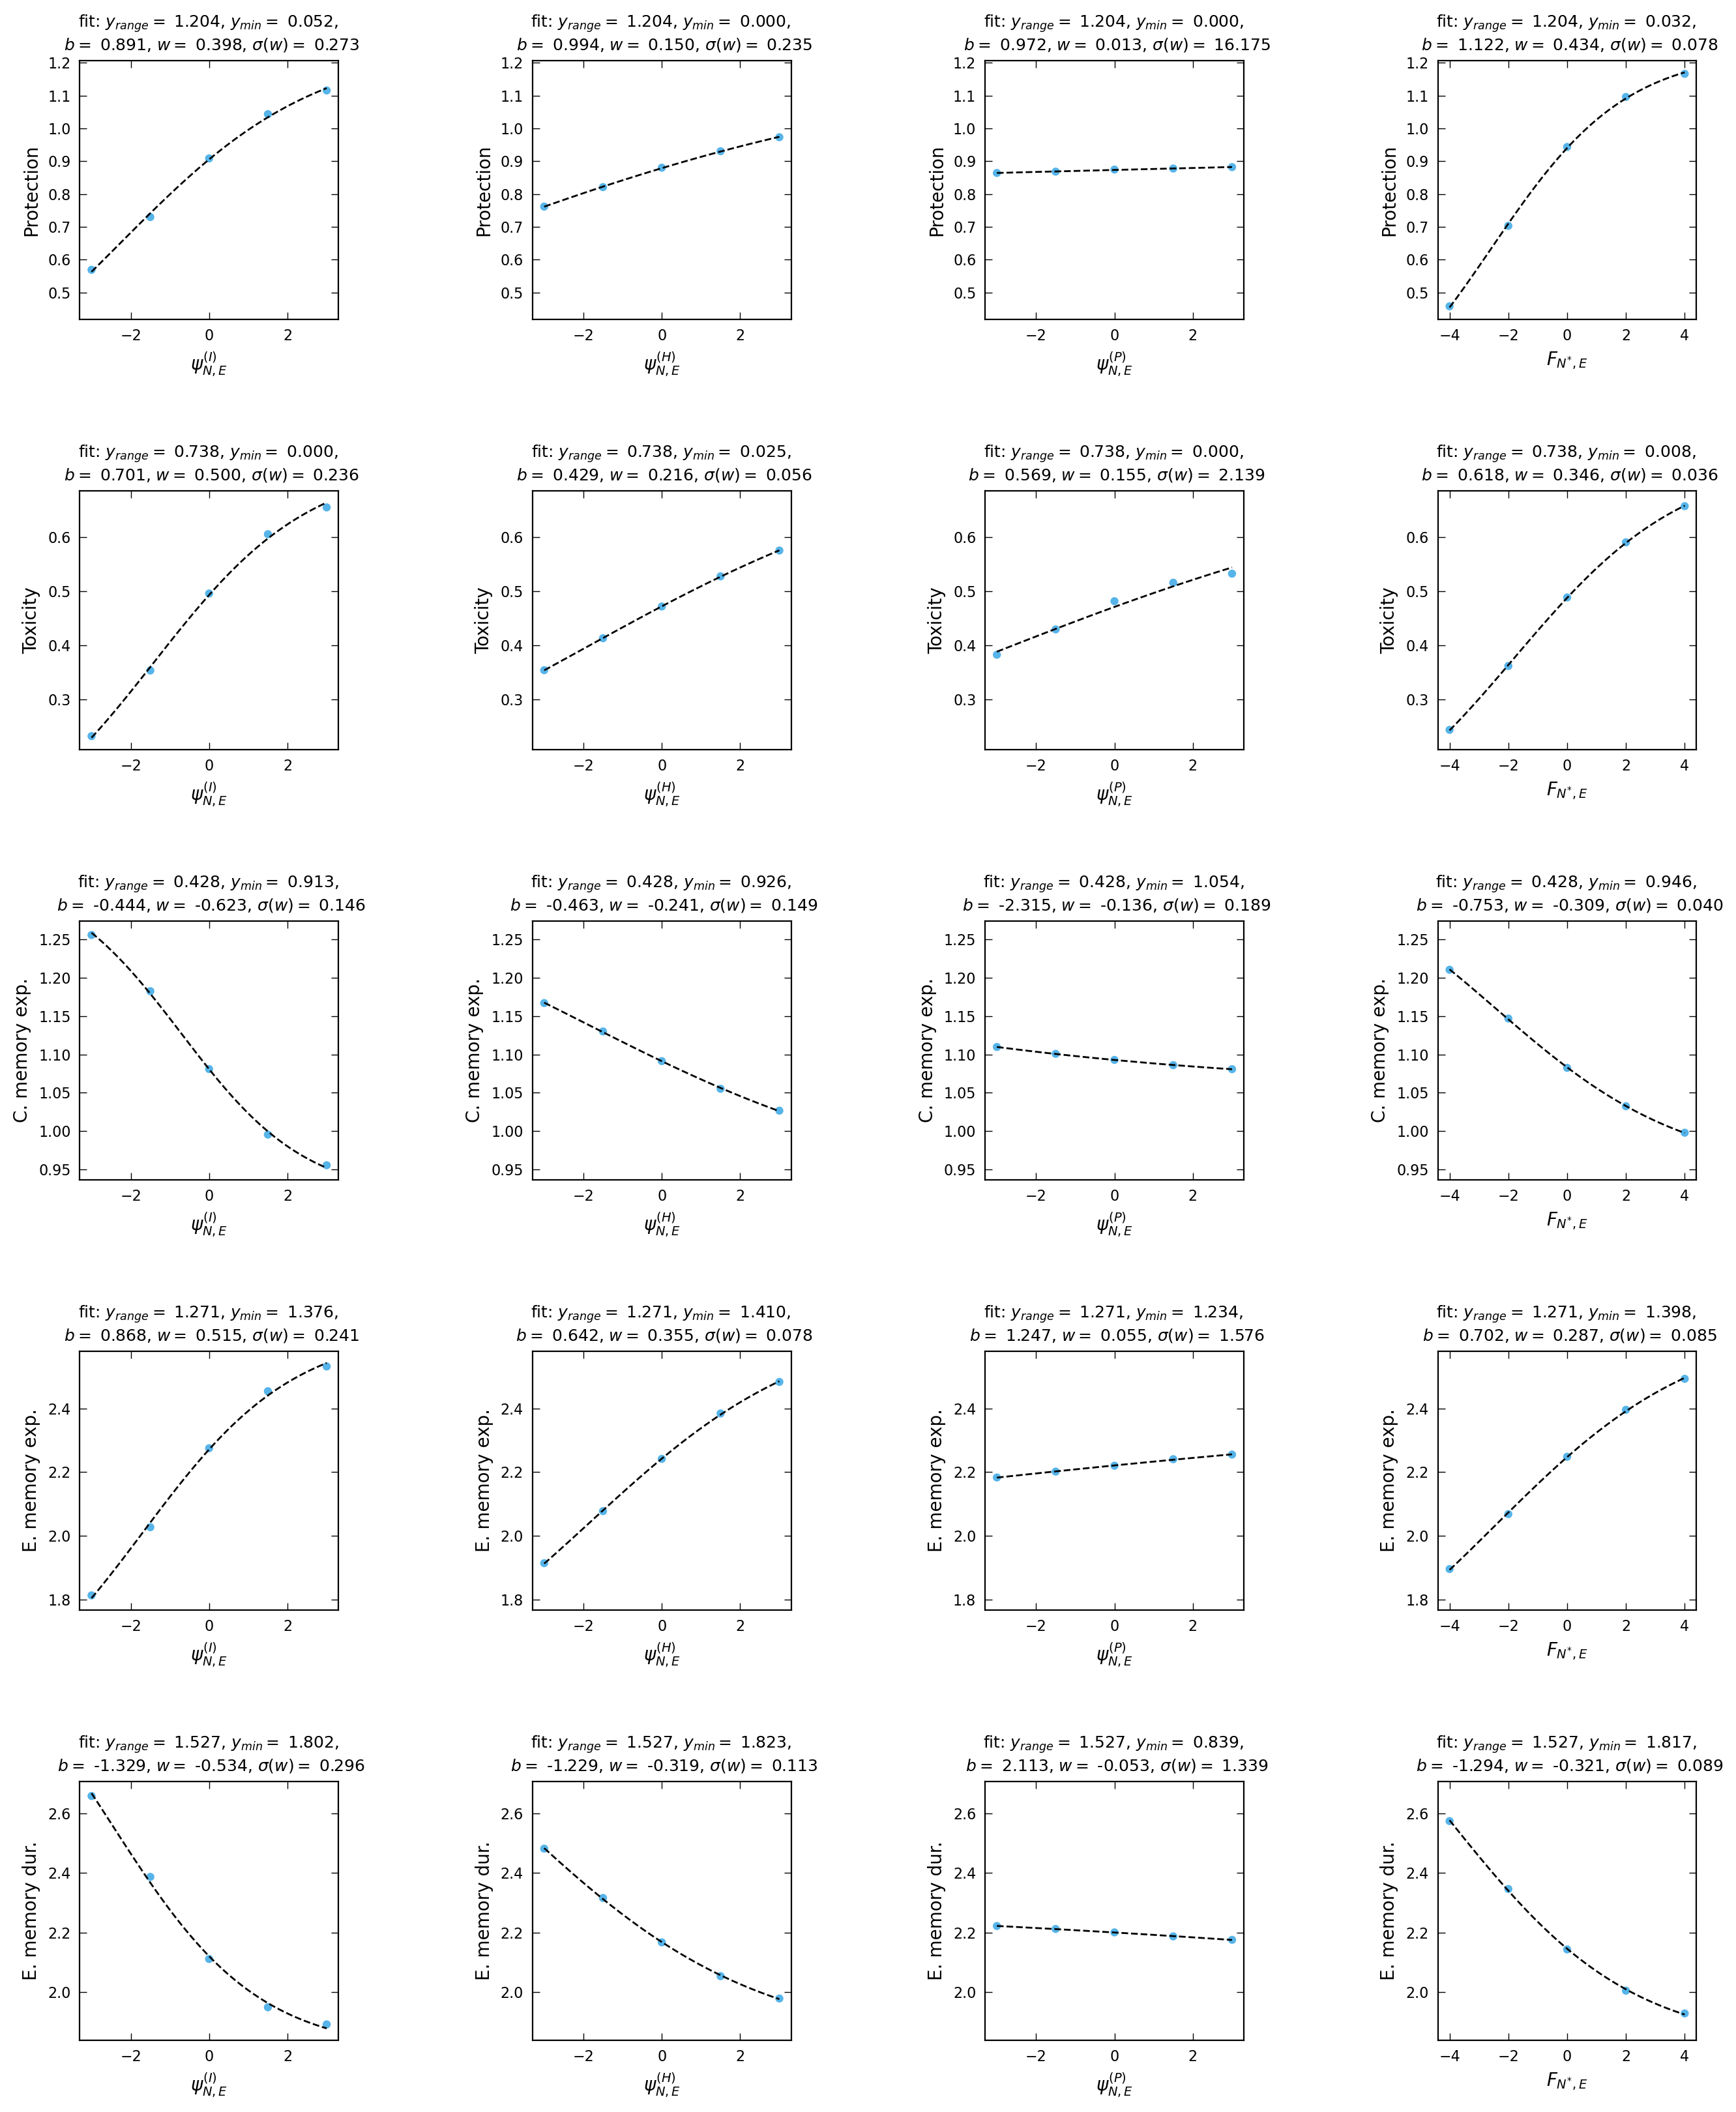

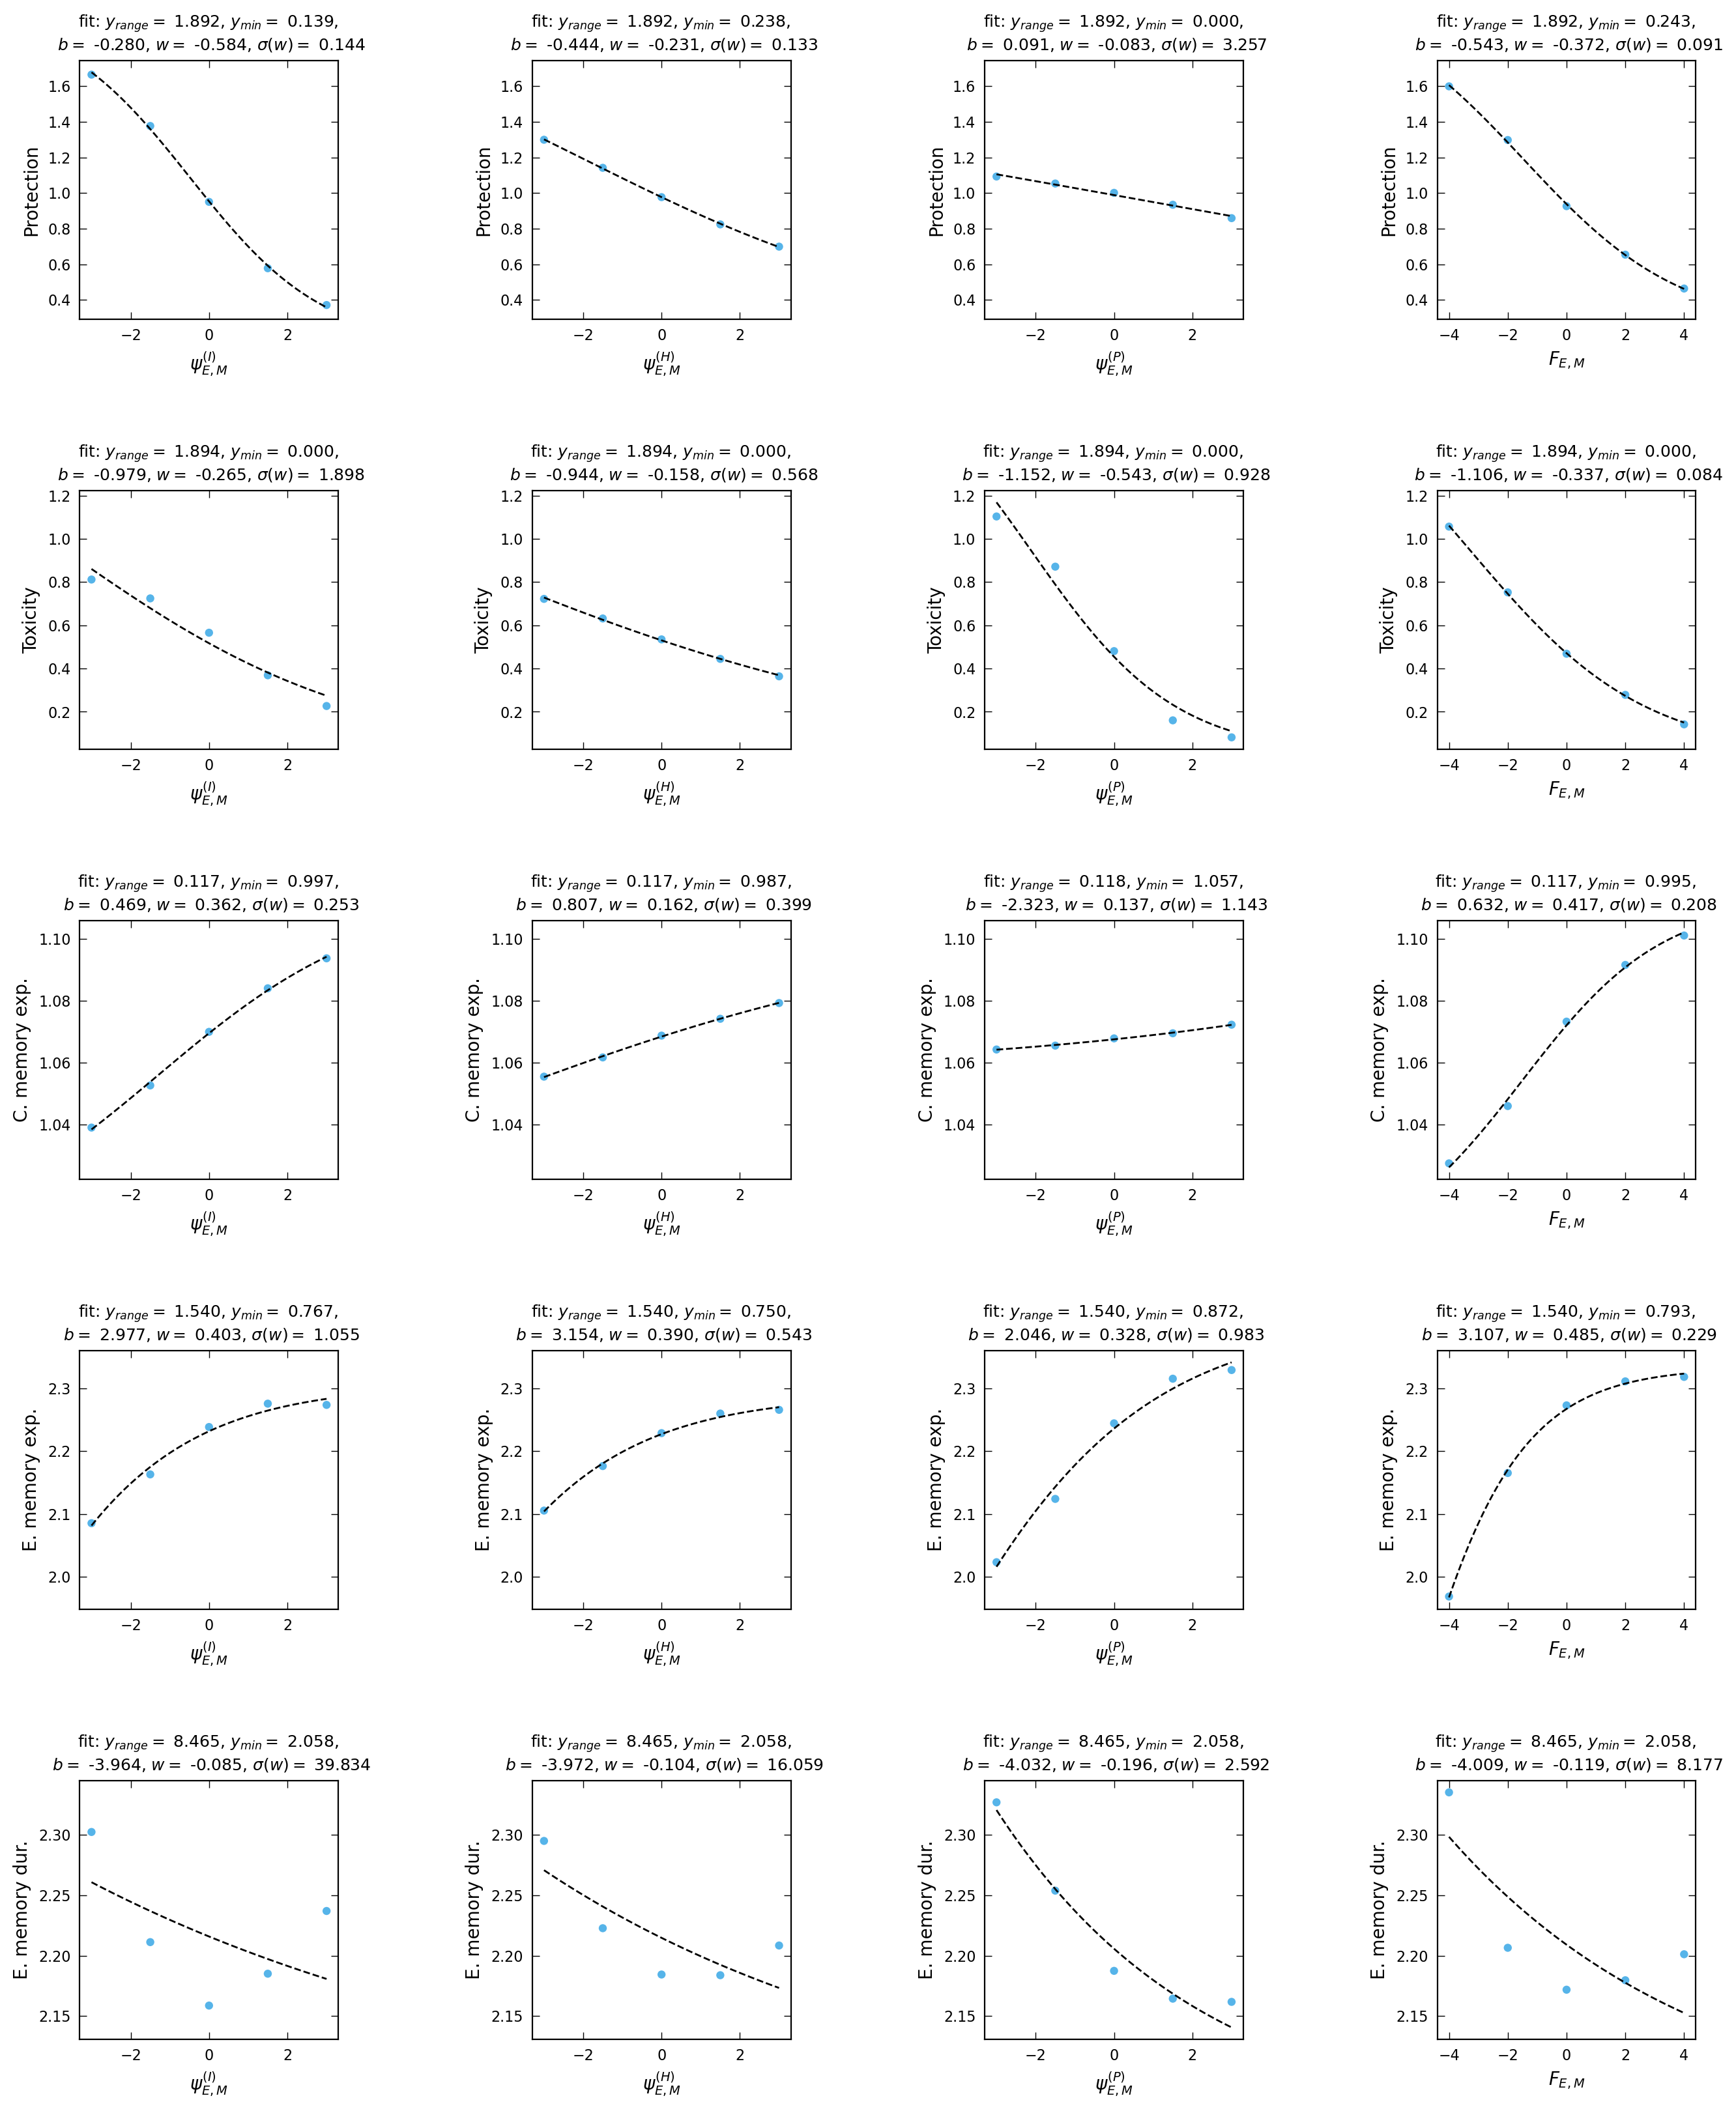

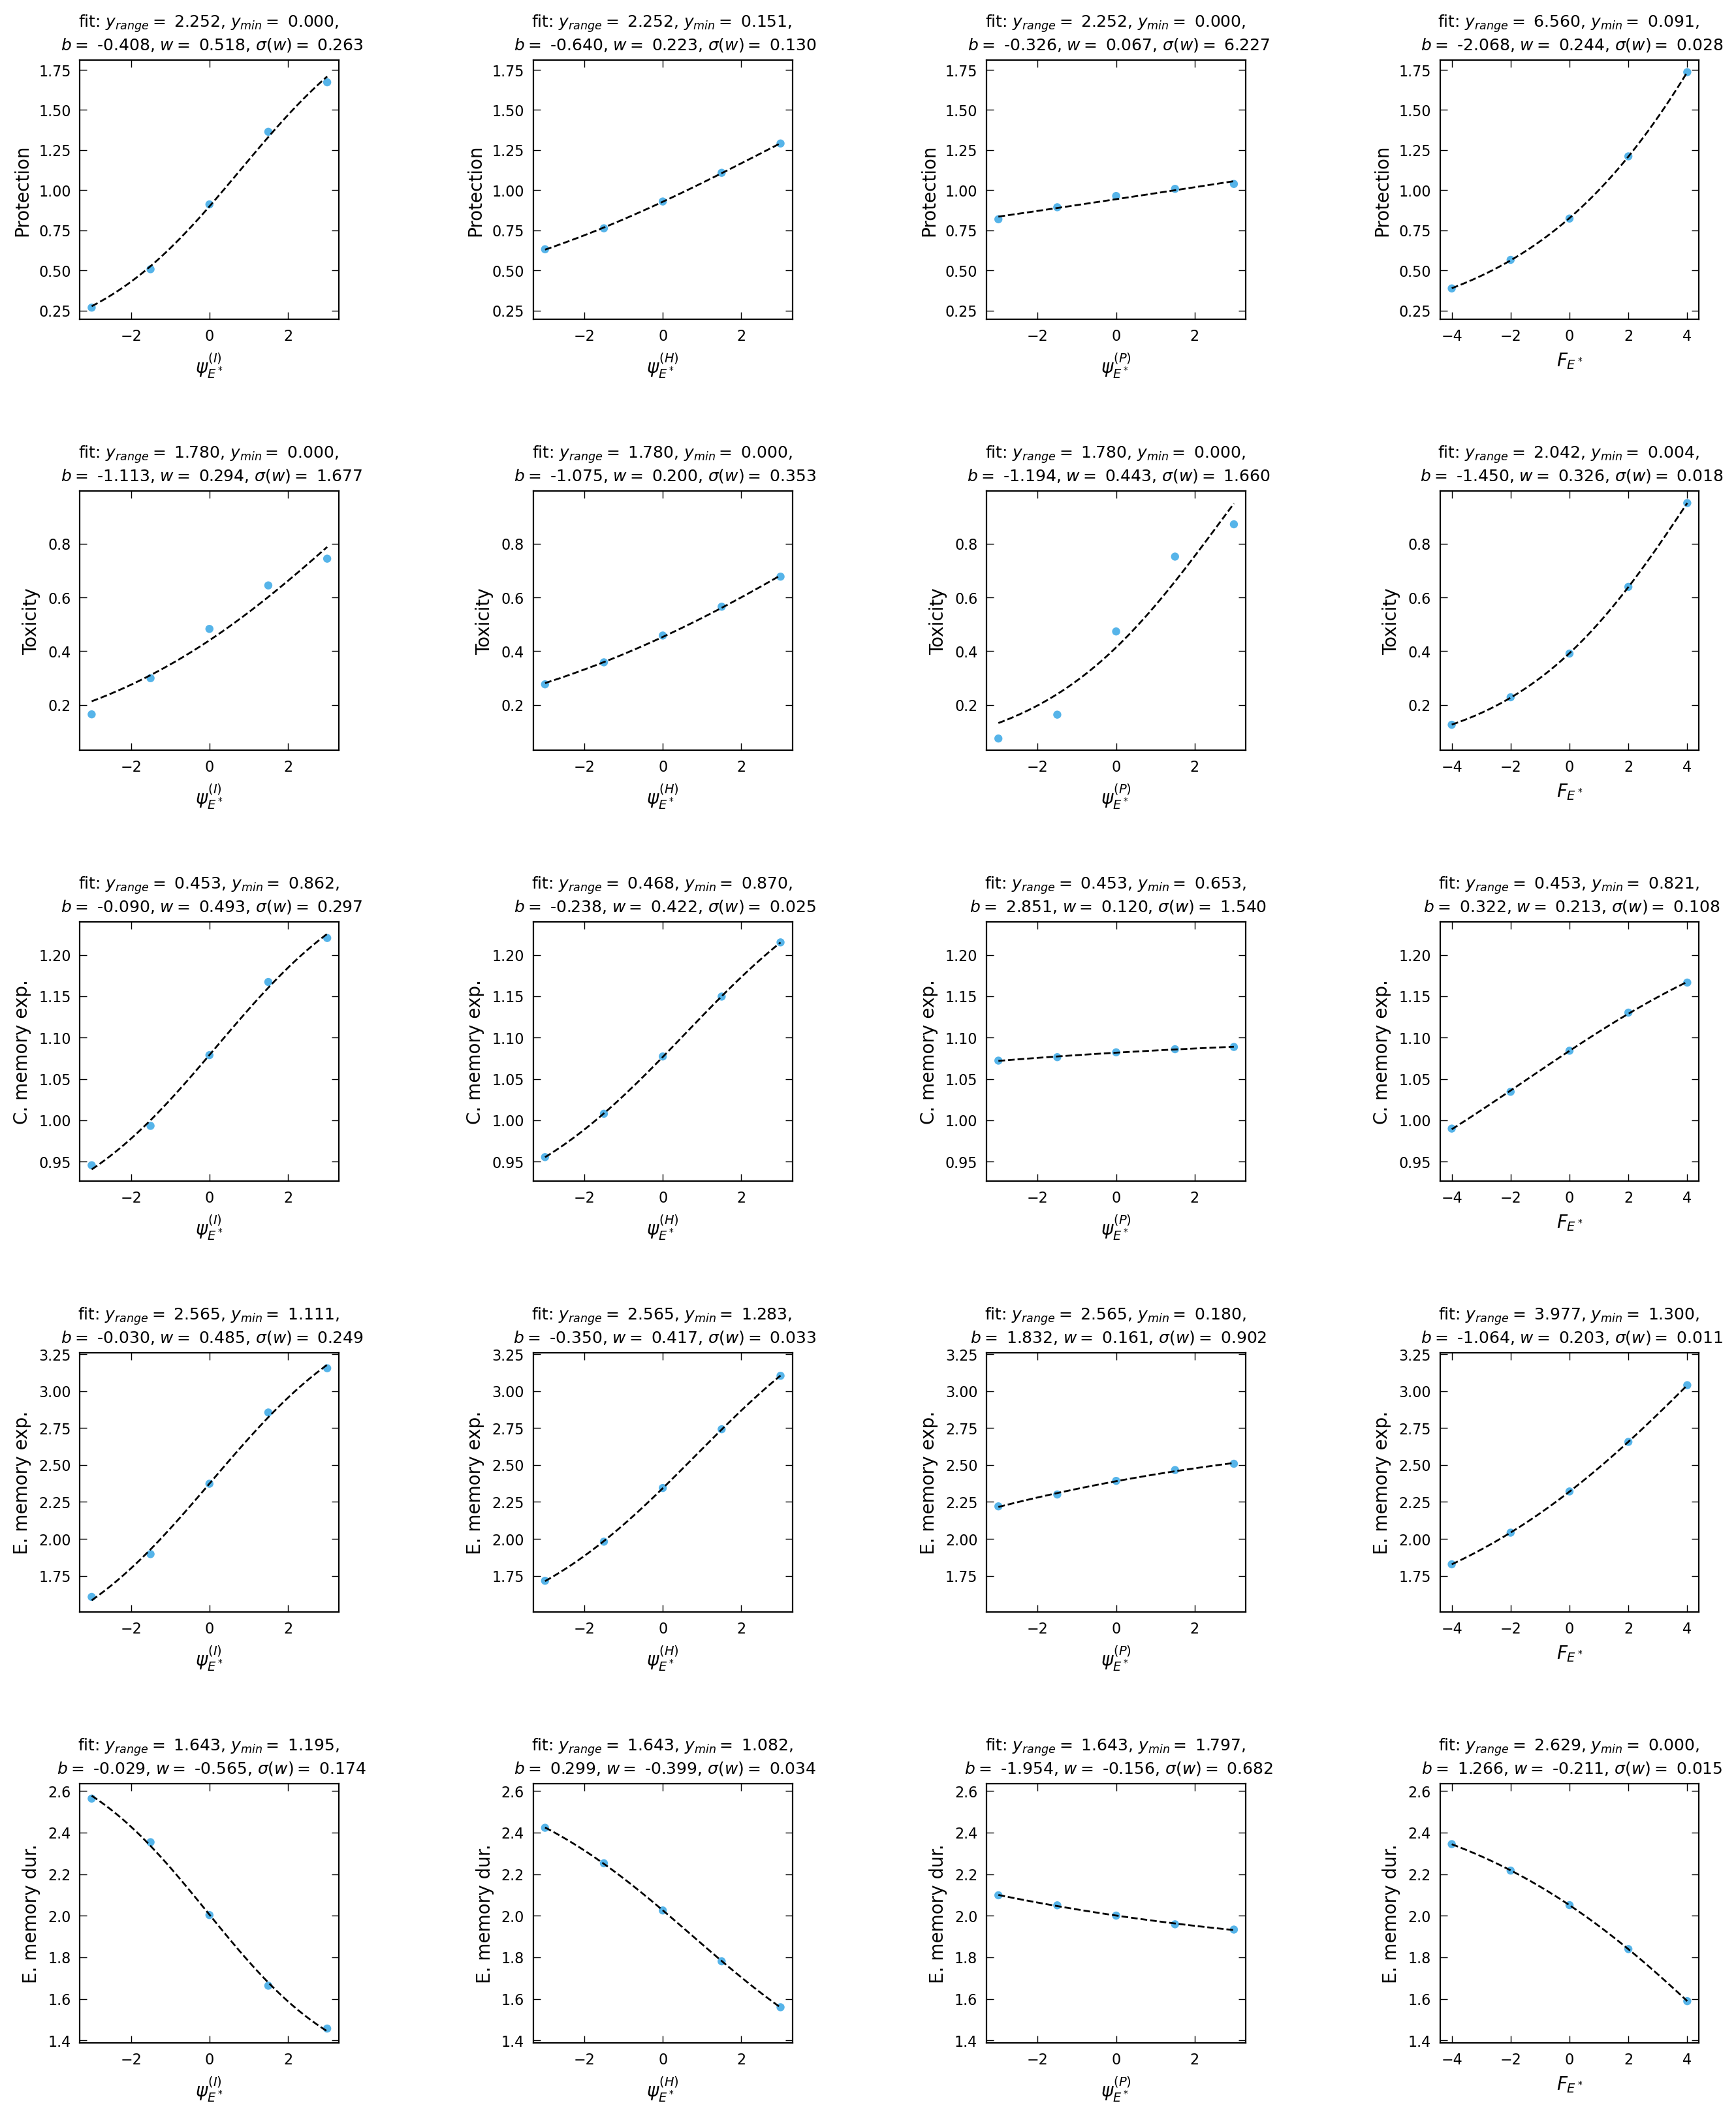

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 130
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min), 0.0 if y_min > 0.0 else y_min] + len(variables)*[-3.0*F0_max] + num_modules*[-3.0*F0_max], 
                                     [1.05*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[3.0*F0_max] + num_modules*[3.0*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [20]:
# View result
perf = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,3.852000,1.591911e-39,0.331325,0.263710,0.565361,1.726210,0.171445,0.034116,0.496844,0.936784,-0.274721,-0.008736,-0.887473,-1.458078,0.358571,0.056466,0.885916,2.088287,-1.975861,1.326178,-2.908929,-7.239675,0.004157,0.000077,0.001607,0.001580,0.001715,0.002416,0.001477,0.001451,0.001664,0.001567,0.001288,0.001181,0.002098,0.002816,0.001147,0.001028,0.001681,0.003014,0.003289,0.003454,0.004952,0.009507,0.01,50000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.044954,3.697417,0.0,0.000000e+00,1.0,0.041058,0.262356,0.000000,0.180523,0.060789,0.045720,NaN
6,1.459888,6.348819e-40,0.159236,0.201922,0.334106,2.031829,0.088370,0.013759,0.265169,0.954645,-0.125765,-0.002051,-0.490144,-1.565545,0.127599,0.022828,0.533956,2.693810,-2.953327,1.328559,-3.025632,-9.987487,0.001695,0.000018,0.001152,0.001162,0.001200,0.002551,0.001015,0.001011,0.001054,0.001105,0.000900,0.000881,0.001111,0.002159,0.000710,0.000670,0.001282,0.005157,0.004590,0.002403,0.003847,0.019283,0.01,100000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.013989,1.390369,0.0,0.000000e+00,1.0,0.009718,0.088992,0.000000,0.094331,0.060789,0.019528,NaN
11,4.868382,1.622138e-15,0.280709,0.940264,0.555300,1.620251,0.157893,0.228690,0.494904,0.908102,-0.261111,-0.071089,-0.942911,-1.405518,0.344215,0.250864,1.003103,2.154838,-1.565592,1.312193,-2.852066,-7.414592,0.005658,0.000111,0.001735,0.002238,0.001888,0.002544,0.001604,0.001632,0.001813,0.001671,0.001372,0.001277,0.002335,0.002934,0.001310,0.001254,0.002034,0.003464,0.002847,0.003772,0.005106,0.011019,0.05,50000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.059991,4.704142,0.0,6.600691e-07,1.0,0.058825,0.342459,0.000000,0.173268,0.266744,0.080889,NaN
16,2.032578,6.127182e-39,0.163023,0.908537,0.406461,1.859474,0.090055,0.105656,0.329235,0.939712,-0.123166,-0.024230,-0.600099,-1.508918,0.145334,0.154881,0.664099,2.588240,-2.454851,1.318752,-2.976138,-9.479467,0.002512,0.000035,0.001470,0.001921,0.001563,0.002599,0.001346,0.001349,0.001430,0.001455,0.001174,0.001149,0.001628,0.002710,0.001007,0.001017,0.001716,0.004955,0.004156,0.003198,0.004781,0.017681,0.05,100000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.020301,2.032578,0.0,0.000000e+00,1.0,0.018562,0.127589,0.000000,0.090385,0.266744,0.029950,NaN
21,9.749377,9.077341e-36,3.200206,0.265227,0.478160,1.870064,1.871617,0.181942,0.385290,1.172319,-0.877421,-0.104222,-0.855390,-0.882197,2.223251,0.286384,1.386308,1.515601,1.143822,2.792659,-2.275592,-2.261062,0.019943,0.000936,0.015845,0.005811,0.006157,0.008916,0.010399,0.005338,0.005601,0.005519,0.003511,0.002155,0.003455,0.002704,0.009214,0.004006,0.006575,0.005503,0.007039,0.014395,0.004860,0.009250,0.25,10000.0,1.500000e-07,50000.0,300.000000,10000000.0,1000.0,0.355205,9.749377,0.0,8.108190e-04,1.0,0.457475,1.256661,5.383929,5.058417,1.663644,0.557237,2.813581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621,0.368421,2.216428e-39,0.260556,2.755080,0.147281,2.532281,0.093513,0.949486,0.099479,0.948038,-0.144265,-1.546697,-0.258391,-1.418245,0.188663,2.357609,0.282880,2.123130,0.522152,1.355602,-2.827585,-

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for protection, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

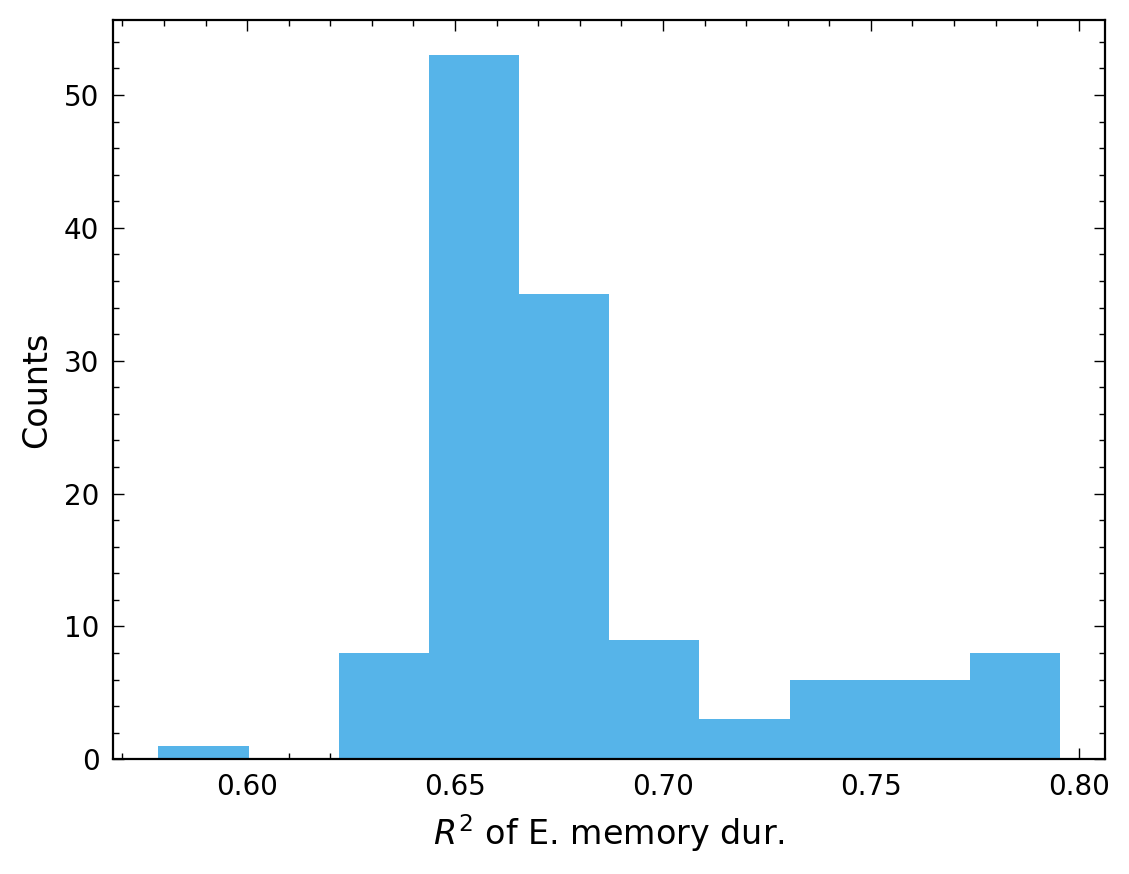

In [11]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

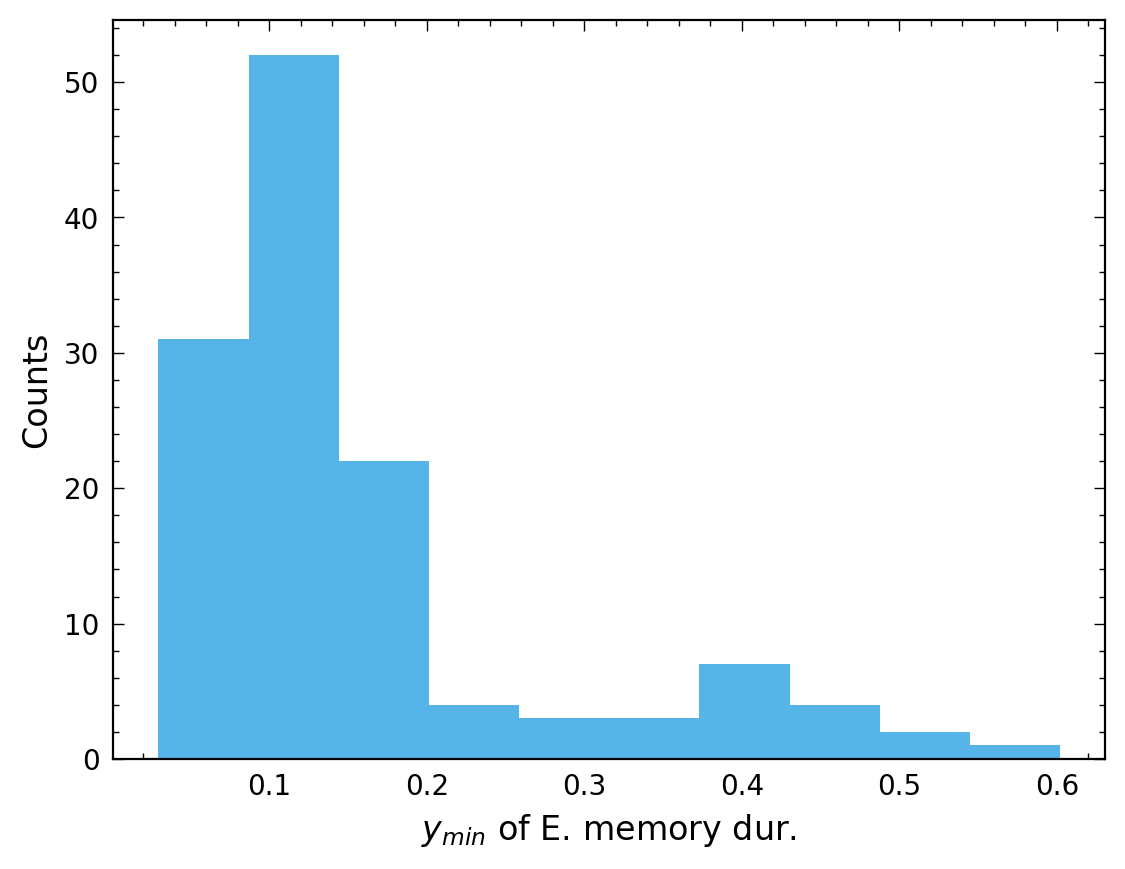

In [12]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

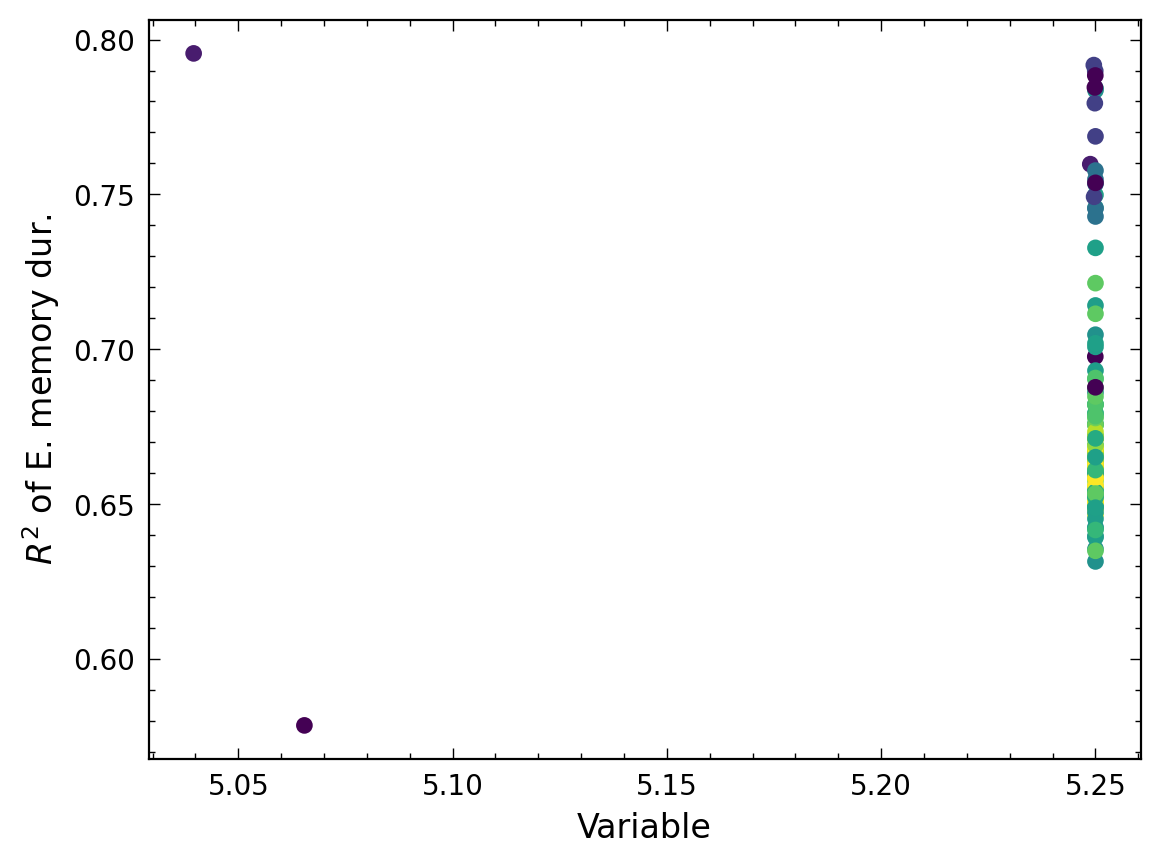

In [13]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)].y_range, model_r_sq, 
            c = 1/impact_data.loc[(impact_data.perf_index == perf)].K_IE, norm=mpl.colors.LogNorm());
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

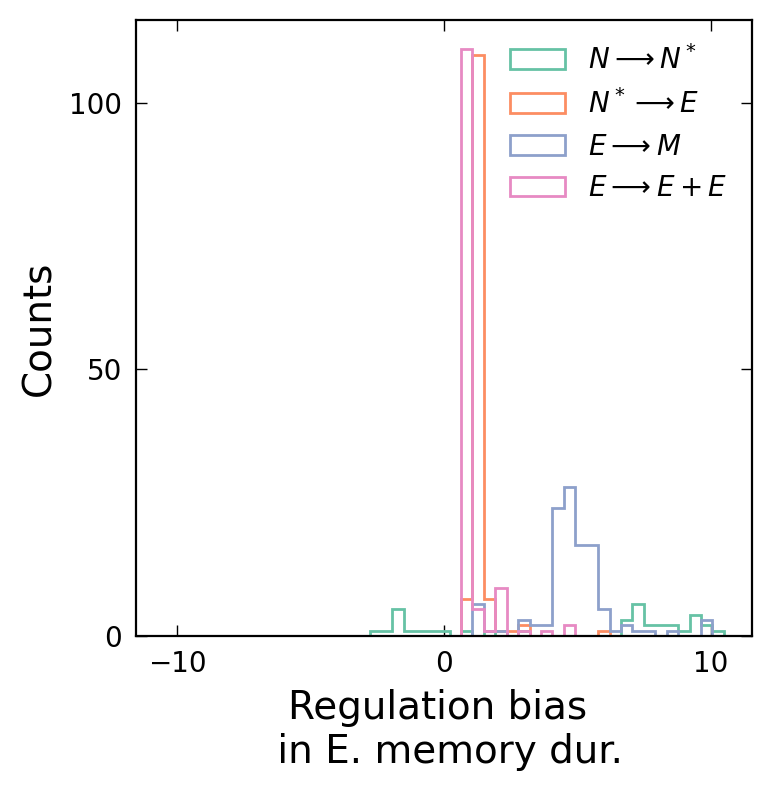

In [14]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

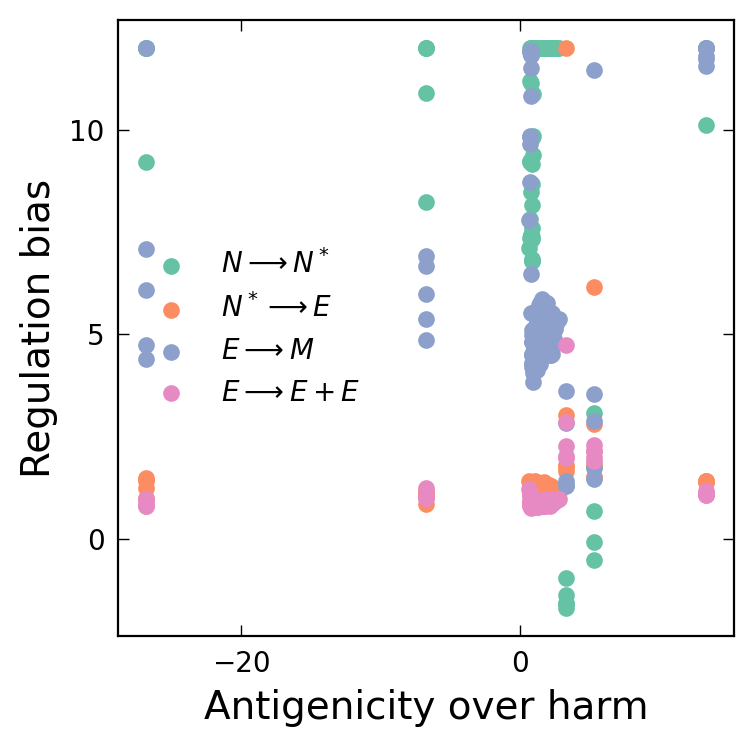

In [15]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

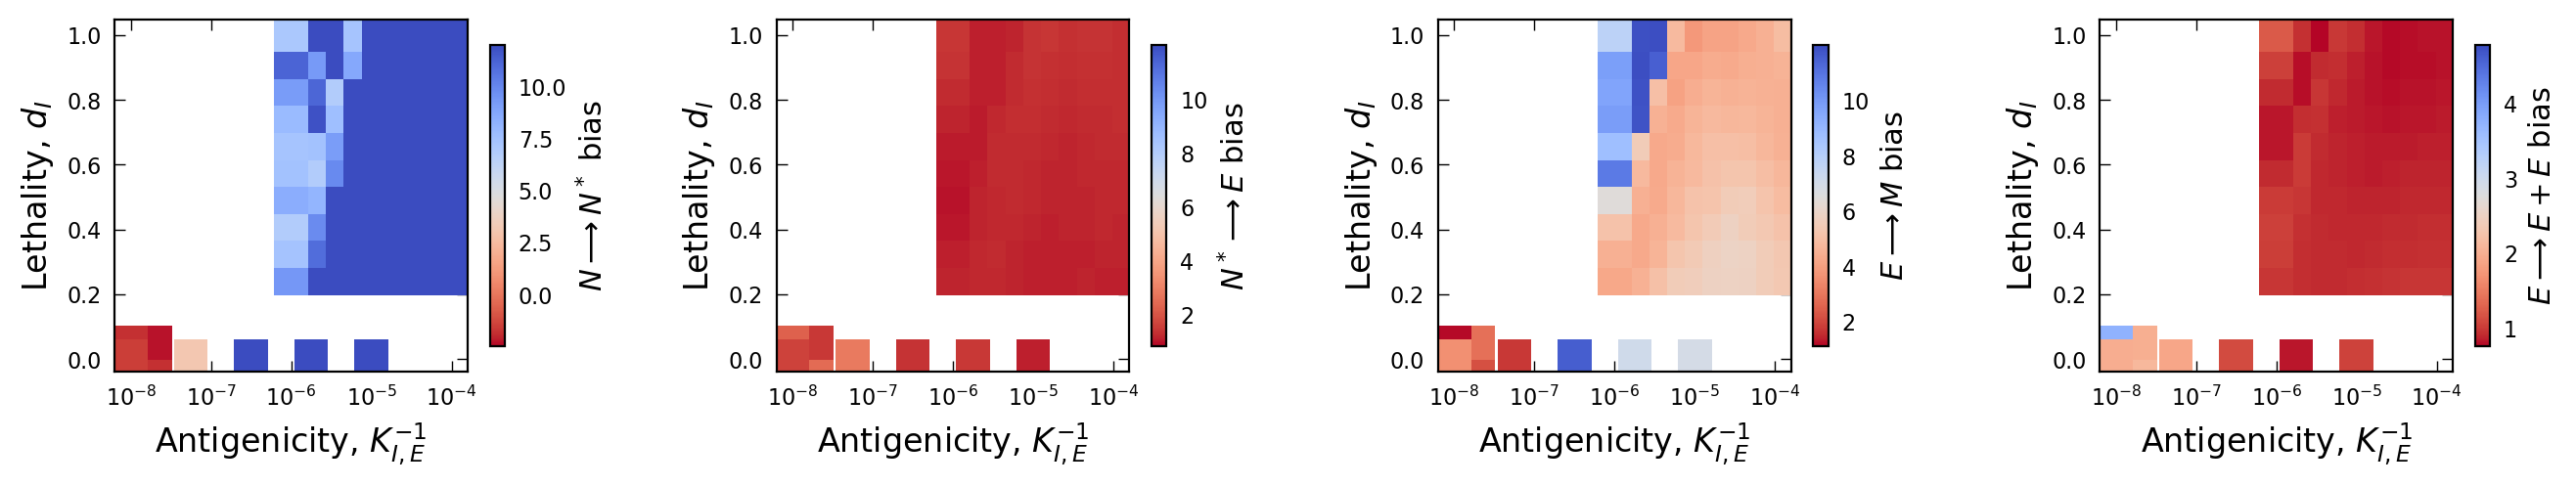

In [16]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

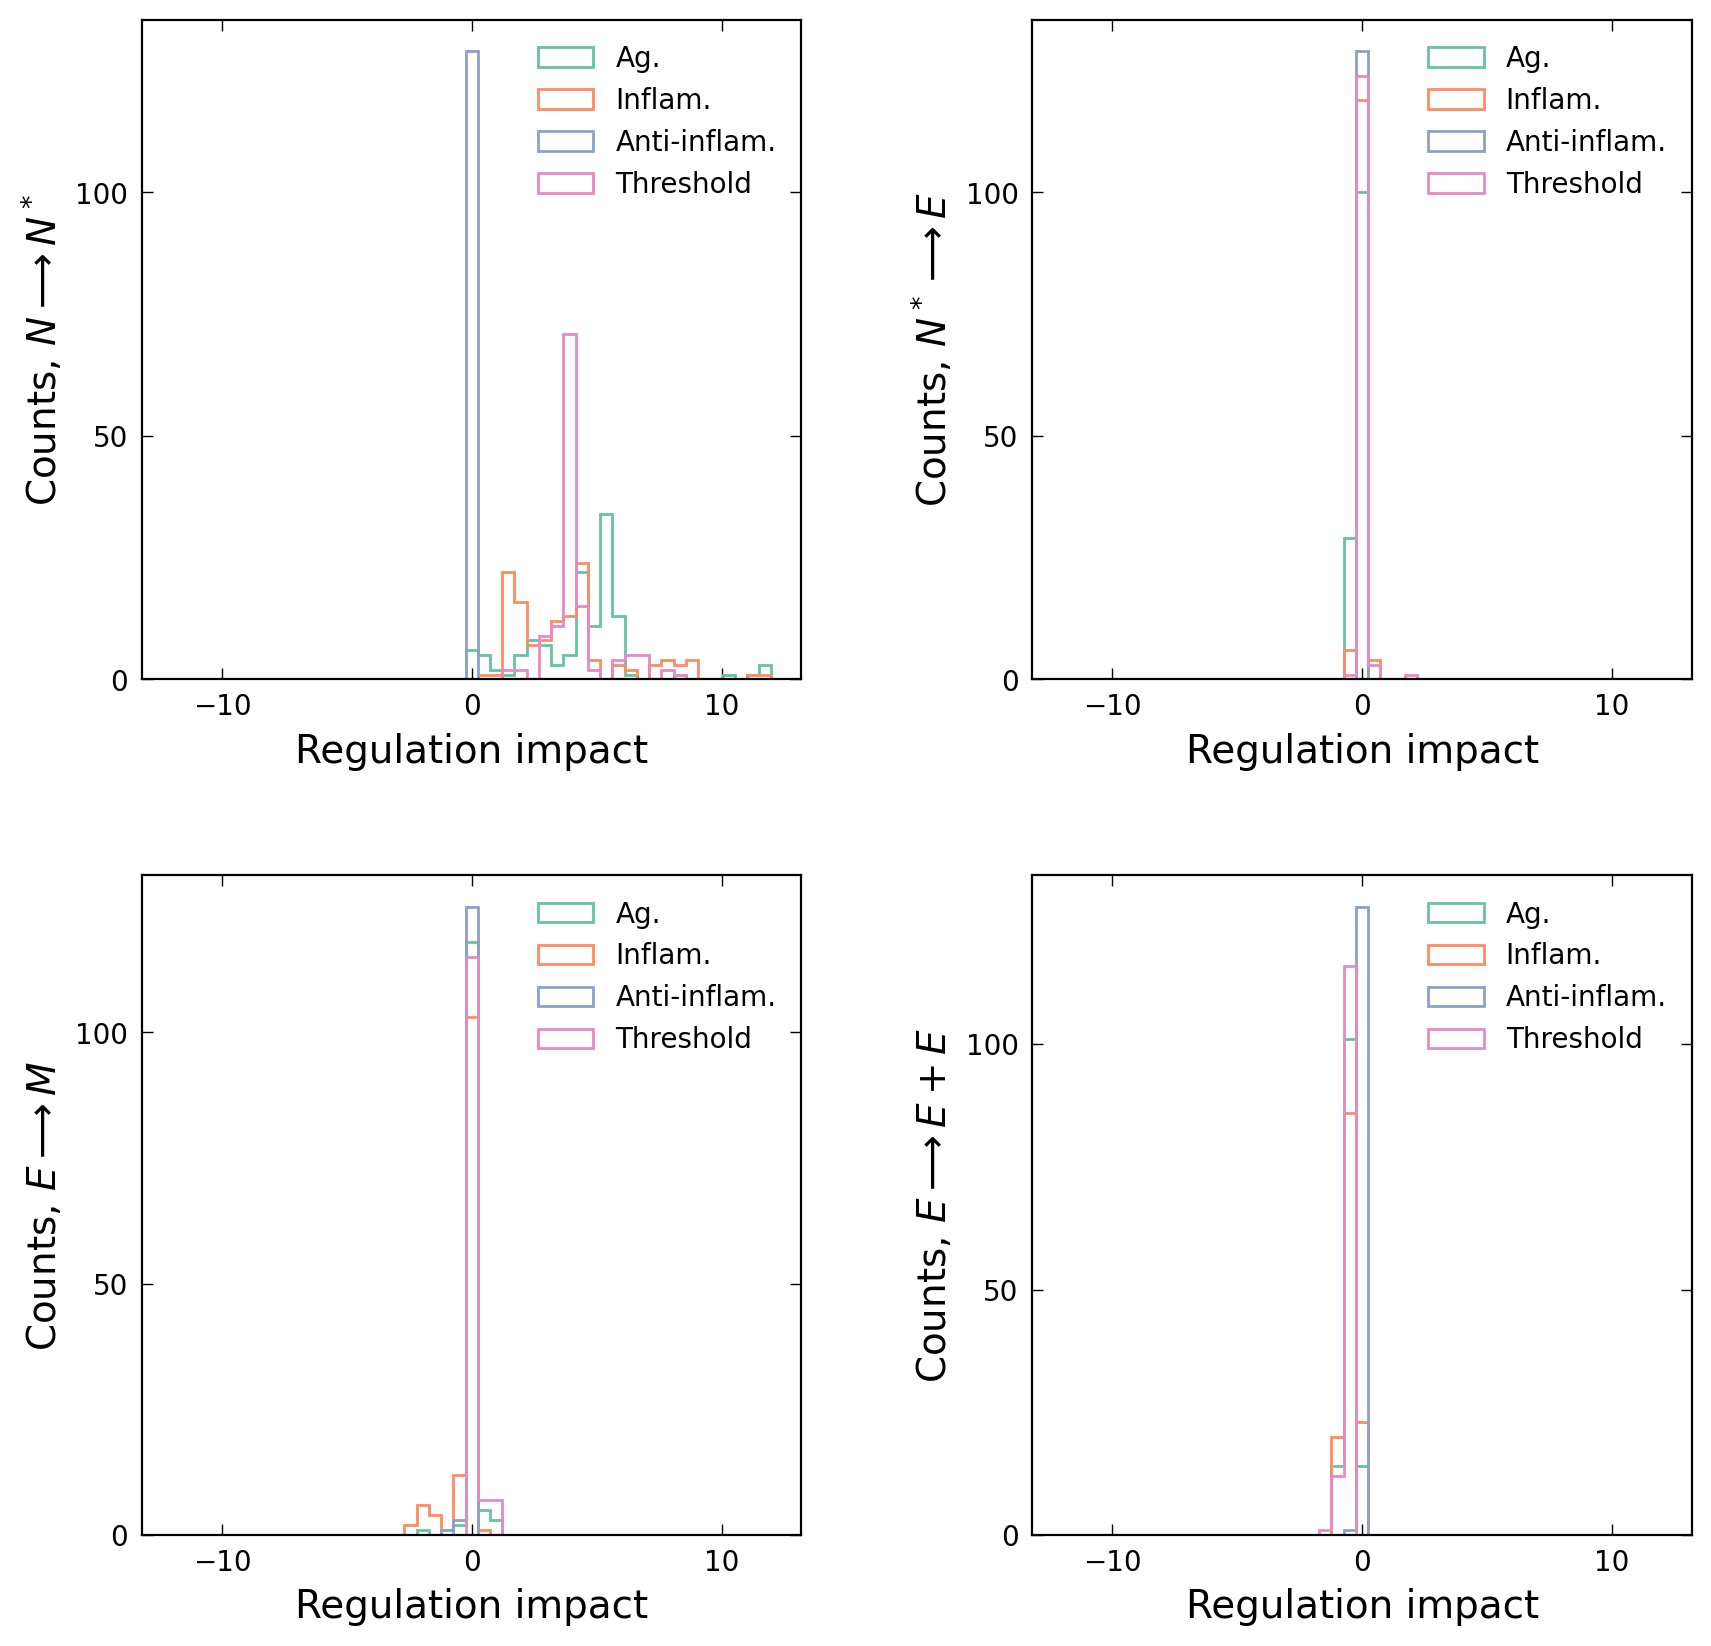

In [17]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*F0_max, 3.0*F0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [21]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,3.852000,1.591911e-39,0.331325,0.263710,0.565361,1.726210,0.171445,0.034116,0.496844,0.936784,-0.274721,-0.008736,-0.887473,-1.458078,0.358571,0.056466,0.885916,2.088287,-1.975861,1.326178,-2.908929,-7.239675,0.004157,0.000077,0.001607,0.001580,0.001715,0.002416,0.001477,0.001451,0.001664,0.001567,0.001288,0.001181,0.002098,0.002816,0.001147,0.001028,0.001681,0.003014,0.003289,0.003454,0.004952,0.009507,0.01,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.044954,3.697417,0.0,0.000000e+00,1.0,0.041058,0.262356,0.0,0.180523,0.060789,0.045720,NaN
6,1.459888,6.348819e-40,0.159236,0.201922,0.334106,2.031829,0.088370,0.013759,0.265169,0.954645,-0.125765,-0.002051,-0.490144,-1.565545,0.127599,0.022828,0.533956,2.693810,-2.953327,1.328559,-3.025632,-9.987487,0.001695,0.000018,0.001152,0.001162,0.001200,0.002551,0.001015,0.001011,0.001054,0.001105,0.000900,0.000881,0.001111,0.002159,0.000710,0.000670,0.001282,0.005157,0.004590,0.002403,0.003847,0.019283,0.01,100000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.013989,1.390369,0.0,0.000000e+00,1.0,0.009718,0.088992,0.0,0.094331,0.060789,0.019528,NaN
11,4.868382,1.622138e-15,0.280709,0.940264,0.555300,1.620251,0.157893,0.228690,0.494904,0.908102,-0.261111,-0.071089,-0.942911,-1.405518,0.344215,0.250864,1.003103,2.154838,-1.565592,1.312193,-2.852066,-7.414592,0.005658,0.000111,0.001735,0.002238,0.001888,0.002544,0.001604,0.001632,0.001813,0.001671,0.001372,0.001277,0.002335,0.002934,0.001310,0.001254,0.002034,0.003464,0.002847,0.003772,0.005106,0.011019,0.05,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.059991,4.704142,0.0,6.600691e-07,1.0,0.058825,0.342459,0.0,0.173268,0.266744,0.080889,NaN
16,2.032578,6.127182e-39,0.163023,0.908537,0.406461,1.859474,0.090055,0.105656,0.329235,0.939712,-0.123166,-0.024230,-0.600099,-1.508918,0.145334,0.154881,0.664099,2.588240,-2.454851,1.318752,-2.976138,-9.479467,0.002512,0.000035,0.001470,0.001921,0.001563,0.002599,0.001346,0.001349,0.001430,0.001455,0.001174,0.001149,0.001628,0.002710,0.001007,0.001017,0.001716,0.004955,0.004156,0.003198,0.004781,0.017681,0.05,100000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.020301,2.032578,0.0,0.000000e+00,1.0,0.018562,0.127589,0.0,0.090385,0.266744,0.029950,NaN


In [22]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == b_C)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
521,2.304075,6.747258e-37,3.034561,0.874379,0.178964,1.138477,1.757830,0.499822,0.102425,0.674781,-1.743948,-0.472285,-0.777014,-1.039125,3.388854,1.003884,0.845057,1.481262,0.786715,1.468042,-2.481732,-1.733562,0.003460,0.000180,0.011380,0.005415,0.004284,0.003386,0.007212,0.004004,0.003507,0.002230,0.005044,0.002433,0.002932,0.002707,0.010126,0.004726,0.004425,0.003786,0.004710,0.006838,0.004970,0.005422,0.01,1.000000e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,0.092312,2.304075,0.0,2.365767e-04,1.0,0.087572,0.300852,2.651569,3.336162,1.135655,0.282097,-6.698971
526,8.077716,8.889430e-39,3.247390,0.929803,0.259425,1.243419,2.128445,0.605565,0.154368,0.863601,-1.352627,-0.353713,-0.938177,-0.954680,3.537935,1.027757,1.367845,1.748170,0.764925,1.877582,-2.401926,-2.170550,0.011985,0.000621,0.012245,0.005680,0.004499,0.003839,0.008639,0.004596,0.003983,0.002892,0.003837,0.002072,0.002988,0.002310,0.010935,0.004914,0.005640,0.004735,0.004666,0.008002,0.004346,0.007449,0.01,1.000000e+05,0.1,50000.0,94.868330,10000000.0,1000000.0,0.308384,8.077716,0.0,7.961941e-04,1.0,0.304322,1.048738,2.651569,3.264122,1.083242,0.434818,-6.698971
531,27.492723,2.392474e-31,3.355880,0.948185,0.334505,1.311225,2.112403,0.600255,0.202863,0.873698,-1.296319,-0.338247,-1.208144,-0.962704,3.083520,0.875657,1.793674,1.727507,0.717346,1.903026,-2.411435,-2.157105,0.042767,0.002273,0.013754,0.006228,0.004996,0.004518,0.009226,0.004943,0.004329,0.003154,0.004020,0.002253,0.003820,0.002498,0.010299,0.004837,0.006977,0.004991,0.004882,0.008697,0.004760,0.007838,0.01,1.000000e+05,0.1,50000.0,300.000000,10000000.0,1000000.0,1.044574,27.492723,0.0,2.587799e-03,1.0,1.117433,3.620028,2.651569,3.205389,1.055910,0.677602,-6.698971
536,92.183650,4.615489e-25,3.469888,0.969164,0.413568,1.377883,2.075716,0.586664,0.256492,0.873873,-1.191291,-0.306543,-1.516147,-0.969573,2.557824,0.718963,2.422634,1.726546,0.662787,1.887216,-2.386468,-2.172636,0.137068,0.007551,0.014297,0.006282,0.005100,0.004906,0.008905,0.004812,0.004284,0.003093,0.003805,0.002261,0.004536,0.002491,0.008603,0.004161,0.008292,0.004931,0.004656,0.008490,0.004746,0.007712,0.01,1.000000e+05,0.1,50000.0,948.683298,10000000.0,1000000.0,3.541116,92.183650,0.0,8.193550e-03,1.0,3.718480,12.259334,2.651569,3.160560,1.017037,1.033834,-6.698971
541,290.542722,1.015737e-36,3.582405,0.987490,0.494357,1.443559,2.057637,0.575187,0.319084,0.882251,-0.991342,-0.240250,-2.024121,-1.029017,1.842866,0.471907,3.062394,1.668447,0.618406,1.906422,-2.338720,-2.061782,0.348786,0.021579,0.013047,0.005534,0.004558,0.004667,0.007565,0.004103,0.003732,0.002681,0.003206,0.002121,0.005329,0.002446,0.005868,0.003534,0.008511,0.003991,0.003899,0.007333,0.004458,0.006152,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,11.950695,290.542722,0.0,2.623868e-02,1.0,10.625792,40.321813,2.651569,3.094453,0.985732,1.409263,-6.698971
546,2.820777,2.781378e-43,1.323818,0.822872,0.166626,1.067295,0.623567,0.384551,0.088976,0.498183,-0.794039,-0.486767,-0.587740,-0.845145,2.061681,1.302932,0.926059,1.771094,0.598017,0.870197,-2.474216,-2.624801,0.006192,0.000174,0.005337,0.004232,0.003295,0.003389,0.003352,0.002834,0.002453,0.001857,0.002547,0.002010,0.002171,0.001976,0.007780,0.005627,0.004674,0.005833,0.004644,0.006506,0.003982,0.010252,0.01,5.623413e+05